In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import yfinance as yf
import matplotlib.pyplot as plt

np.random.seed(42)

In [4]:
tickers = ["AAPL","MSFT","GOOGL","JPM","GS"]
data=yf.download(tickers, start="2020-01-01", end ="2026-01-01")
prices=data["Close"]

log_returns = np.log(prices/prices.shift(1)).dropna()

mean_returns = log_returns.mean() * 252 # Expected returns in a trading year
cov_matrix= log_returns.cov() * 252 # Annualized covariance matrix

print("Expected annual returns:")
print(mean_returns.round(4))
print("\nCovariance Matrix:")
print(cov_matrix.round(5))

[*********************100%***********************]  5 of 5 completed

Expected annual returns:
Ticker
AAPL     0.2211
GOOGL    0.2555
GS       0.2449
JPM      0.1658
MSFT     0.1930
dtype: float64

Covariance Matrix:
Ticker     AAPL    GOOGL       GS      JPM     MSFT
Ticker                                             
AAPL    0.10074  0.06446  0.05046  0.04227  0.06663
GOOGL   0.06446  0.10543  0.04874  0.04126  0.06729
GS      0.05046  0.04874  0.10719  0.08476  0.04650
JPM     0.04227  0.04126  0.08476  0.09814  0.03970
MSFT    0.06663  0.06729  0.04650  0.03970  0.08725


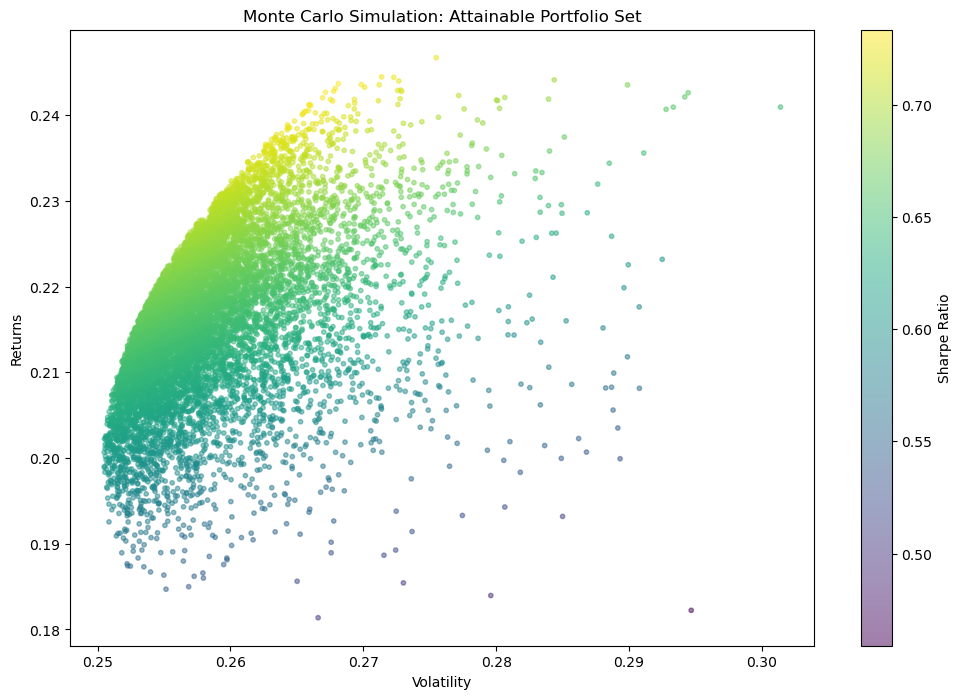

In [8]:
# Monte Carlo Simulation of Attainable set
# Sample many weights and find return and var of each. Gives an intuitive idea of what the boundary region will be.

n_assets= len(tickers)
n_portfolios= 10000

results= np.zeros((3,n_portfolios)) # create an array for our return, volatility, and sharpe's ratio before we calculate them

risk_free_rate = 0.047 # US 10 Year Treasury highest risk-free rate according to CNBC

for i in range(n_portfolios):
    weights= np.random.random(n_assets)
    weights /= weights.sum()

    #portfolio expected return: w^T * mu ( * = dot product)
    port_returns= np.dot(weights,mean_returns)

    #portfolio variance: w^T * C * w 
    port_var= np.dot(weights.T,np.dot(cov_matrix,weights))
    port_vol = np.sqrt(port_var)

    #Sharpe ratio: (average annual returns - risk free rate)/ volatility
    sharpe= (port_returns - risk_free_rate)/port_vol

    results[0,i] = port_returns
    results[1,i] = port_vol
    results[2,i] = sharpe

#Plot attainable set
plt.figure(figsize=(12,8))
scatter = plt.scatter(results[1,:], results[0,:],c=results[2,:],cmap="viridis",alpha=0.5,s=10)
plt.colorbar(scatter,label="Sharpe Ratio")
plt.xlabel("Volatility")
plt.ylabel("Returns")
plt.title("Monte Carlo Simulation: Attainable Portfolio Set")
plt.show()


In [9]:
# Note: We notice that the left boundary formed by the scatter plot is the minimum variance line.
# Above the global minimum of the min variance line is the efficient frontier


In [13]:
# Actual Minimum Variance Portfolio

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return np.sqrt(np.dot(weights.T,np.dot(cov_matrix, weights))) # Gives the SD

# min variance line = min(Var()) constrained to w^T * 1 = 1 (sum of weights =1)
constraints={"type":'eq','fun':lambda w : np.sum(w)-1}

# bound to 0<=w<=1 to assume no short selling
bounds=tuple((0,1) for _ in range(n_assets))

#Guess weights to be equal
w0 = np.array([1/n_assets]*n_assets)

min_var_result = minimize(portfolio_volatility,w0,args=(mean_returns,cov_matrix),method="SLSQP",bounds=bounds,constraints=constraints)
# SQLSP for constrained opt problems

min_var_weights = min_var_result.x
min_var_returns = np.dot(min_var_weights,mean_returns)
min_var_vol = portfolio_volatility(min_var_weights,mean_returns,cov_matrix)

print("Minimum Variance Portfolio")
for ticker, weight in zip(tickers,min_var_weights):
    print(f" {ticker}: {weight:.2%}")
print(f"\nExpected Returns: {min_var_returns:.2%}")
print(f"\nVolatility: {min_var_vol:.2%}")

Minimum Variance Portfolio
 AAPL: 16.20%
 MSFT: 15.17%
 GOOGL: 1.84%
 JPM: 36.79%
 GS: 30.00%

Expected Returns: 19.80%

Volatility: 25.03%


In [19]:
# Max Sharpe Ratio Portfolio/ Market Portfolio where theres highest reqrd per unit of risk

def negative_sharpe(weights,mean_returns,cov_matrix,risk_free_rate):
    port_return = np.dot(weights,mean_returns)
    port_vol= np.sqrt(np.dot(weights.T,np.dot(cov_matrix, weights)))
    sharpe = (port_returns - risk_free_rate) / port_vol
    return -sharpe

max_sharpe_result= minimize(negative_sharpe,w0,args=(mean_returns,cov_matrix, risk_free_rate), method="SLSQP",bounds=bounds,constraints=constraints)

max_sharpe_weights = max_sharpe_result.x
max_sharpe_return= np.dot(max_sharpe_weights, mean_returns)
max_sharpe_vol= np.sqrt(np.dot(max_sharpe_weights.T, np.dot(cov_matrix,max_sharpe_weights)))
max_sharpe_ratio=(max_sharpe_return-risk_free_rate)/max_sharpe_vol

print("Maximum Sharpe Ratio Portfolio:")
for ticker, weight in zip(tickers, max_sharpe_weights):
    print(f"{ticker}: {weight:.2%}")
print(f"\nExpected Return: {max_sharpe_return:.2%}")
print(f"Expected volatility: {max_sharpe_vol: .2%}")
print(f"Sharpe ratio: {max_sharpe_ratio:.4f}")


Maximum Sharpe Ratio Portfolio:
AAPL: 16.32%
MSFT: 15.10%
GOOGL: 1.83%
JPM: 36.74%
GS: 30.00%

Expected Return: 19.80%
Expected volatility:  25.03%
Sharpe ratio: 0.6031


In [21]:
# Efficient Frontier Curve

def minimize_volatility_for_target(target_return,mean_returns,cov_matrix):
    n=len(mean_returns)
    constraints = [{'type': 'eq','fun': lambda w: np.sum(w)-1}, 
                  {'type': 'eq','fun': lambda w: np.dot(w,mean_returns)-target_return}]
    bounds = tuple((0,1) for _ in range(n))
    w0=np.array([1/n]*n)
    result= minimize(portfolio_volatility,w0,args=(mean_returns, cov_matrix),method="SLSQP",bounds=bounds, constraints=constraints)
    return result.fun

# Creates range of target returns. runs optimizer 100 times for each target return level. For each target return it will find portfolio with lowest volatility
# Collection of those creates an effiecient frontier
target_returns = np.linspace(min_var_returns,mean_returns.max(),100)
frontier_volatilities = [minimize_volatility_for_target(r, mean_returns,cov_matrix) for r in target_returns]

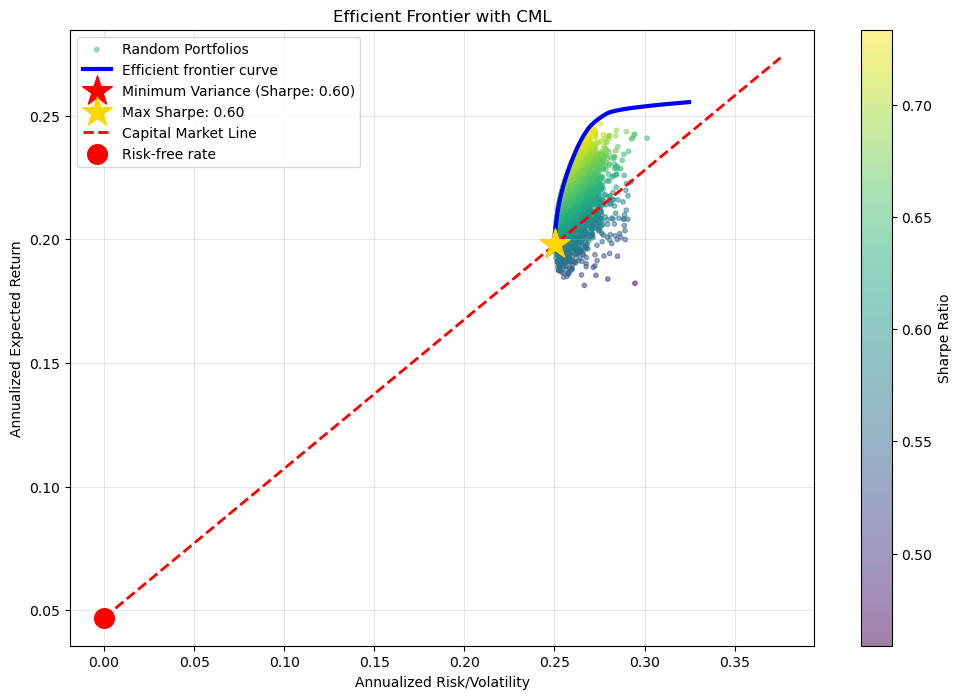

In [30]:
plt.figure(figsize=(12,8))

sc=plt.scatter(results[1,:], results[0,:],c=results[2,:],cmap="viridis",alpha=0.5,s=10,label="Random Portfolios")

plt.plot(frontier_volatilities,target_returns,'b-',linewidth=3,label="Efficient frontier curve")

plt.scatter(min_var_vol,min_var_returns,marker="*",color="red",s=500,zorder=5,
            label=f"Minimum Variance (Sharpe: {(min_var_returns-risk_free_rate)/min_var_vol:.2f})")

plt.scatter(max_sharpe_vol,max_sharpe_return,marker="*",color="gold", s=500,zorder=5,label=f'Max Sharpe: {max_sharpe_ratio:.2f}')

#capital market line
cml_x= np.linspace(0,max_sharpe_vol*1.5,100)
cml_y= risk_free_rate + (max_sharpe_ratio * cml_x)
plt.plot(cml_x,cml_y,'r--', linewidth=2,label='Capital Market Line')
plt.scatter(0,risk_free_rate,marker="o",color='red',s=200,zorder=5,label='Risk-free rate')

plt.colorbar(sc, label="Sharpe Ratio")
plt.xlabel('Annualized Risk/Volatility')
plt.ylabel('Annualized Expected Return')
plt.title('Efficient Frontier with CML')
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
Here, I implemented the Markowitz mean-variance framework on five real assets using data from the past 6 years (2020-2026). Using 10000 
randomly weighted portfolios, the Monte Carlo simulation showed the full attainable set in the risk-return space showing the hyperbolic
boundary of the minimum variance line. The minimum variance portfolio is at the leftmost point of the frotier and represents the lowest
achievable risk regradless of return target. The max Sharpe ratio portfolio finds the tangency point where the CML touche sthe frotier which
tells us the optimal risk to return balance. JP Morgan Chase had the largest allocation in the maxximum Sharpe portfolio (36.74%) which 
reflects its outsized returns over the 6 year period. The key limiattion here is that the optimizer I built is only looking backward at 
existing data and does not guarantee that past performance predicts futute returns.

SyntaxError: invalid syntax (703116362.py, line 1)